In [1]:
!pip install transformers datasets seqeval accelerate


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import json
import gc
import os
import re
import random
import pickle
import time
import copy
from enum import Enum
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    get_linear_schedule_with_warmup,
)
from seqeval.metrics import f1_score, precision_score, recall_score, classification_report
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# --- Пути ---
BASE_DIR      = Path("E:/Code/Poliforge/Polyforge-AI/Polyforge-AI")
DATA_RAW_DIR  = BASE_DIR / "data" / "raw"
DATA_PROC_DIR = BASE_DIR / "data" / "processed"
DATA_CFG_DIR  = BASE_DIR / "data" / "configs"
MODELS_DIR    = BASE_DIR / "models" / "nlp_model_bert"
DATA_PROC_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# --- GPU ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# --- Воспроизводимость ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# --- BIO-метки ---
LABELS     = ["O", "B-PROP_NAME", "I-PROP_NAME", "B-PROP_VAL", "I-PROP_VAL"]
LABEL2ID   = {l: i for i, l in enumerate(LABELS)}
ID2LABEL   = {i: l for l, i in LABEL2ID.items()}
NUM_LABELS = len(LABELS)

# --- Категории ---
class Cat(str, Enum):
    LOW    = "low"
    MEDIUM = "medium"
    HIGH   = "high"

print(f"Метки BIO: {LABELS}")
print(f"Всего меток: {NUM_LABELS}  ← было 111, стало 5")

Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
VRAM: 6.4 GB
Метки BIO: ['O', 'B-PROP_NAME', 'I-PROP_NAME', 'B-PROP_VAL', 'I-PROP_VAL']
Всего меток: 5  ← было 111, стало 5


In [3]:
# ============================================================
# БЛОК 1: Загрузка данных и конфигов
# ============================================================
with open(DATA_CFG_DIR / "param_config.json", encoding="utf-8") as f:
    PARAM_CONFIG: dict = json.load(f)

with open(DATA_CFG_DIR / "property_mapping.json", encoding="utf-8") as f:
    raw = json.load(f)
    PROPERTY_MAPPING = raw["PROPERTY_MAPPING"]

with open(DATA_CFG_DIR / "start_phrases.json", encoding="utf-8") as f:
    START_PHRASES: list[str] = json.load(f)["START_PHRASES"]

with open(DATA_CFG_DIR / "purposes.json", encoding="utf-8") as f:
    PURPOSES: list[str] = json.load(f)["PURPOSES"]

PROPERTY_COLS = list(PROPERTY_MAPPING.keys())

# --- Загрузка датасета полимеров ---
df = pd.read_csv(DATA_RAW_DIR / "polyOne_aa.csv").dropna(subset=["smiles"])
coverage = df[PROPERTY_COLS].notna().mean()
print(f"Молекул: {len(df)}, свойств: {len(PROPERTY_COLS)}")
print(f"Медианное покрытие: {coverage.median():.1%}")

# --- Пороги для категоризации ---
def compute_thresholds(df, cols):
    t = {}
    for col in cols:
        if col not in df.columns:
            continue
        v = df[col].dropna()
        if len(v) < 10:
            continue
        t[col] = {
            "low": float(v.quantile(0.33)),
            "high": float(v.quantile(0.67)),
            "min": float(v.min()),
            "max": float(v.max()),
        }
    return t

THRESHOLDS = compute_thresholds(df, PROPERTY_COLS)
print(f"Порогов рассчитано: {len(THRESHOLDS)}")

Молекул: 500000, свойств: 37
Медианное покрытие: 100.0%
Порогов рассчитано: 37


In [36]:
# ============================================================
# БЛОК 2: Генератор — числовые И категориальные запросы
# ============================================================
import random
import pickle
import re
from pathlib import Path
from tqdm import tqdm

# ============================================================
# 2.1 СЛОВАРИ
# ============================================================

PARAM_UNITS = {
    "Tm": "К", "Tg": "К", "Td": "К",
    "rho": "г/см³", "YM": "МПа", "TSb": "МПа", "TSy": "МПа",
    "CED": "Дж/см³", "Cp": "Дж/(г·К)", "LOI": "%",
    "Xc": "%", "Xe": "моль/м³", "epsb": "кВ/мм", "epsc": "",
    "permCO2": "Баррер", "permO2": "Баррер", "permN2": "Баррер",
    "permH2": "Баррер", "permCH4": "Баррер", "permHe": "Баррер",
    "Ei": "эВ", "Eea": "эВ", "Eat": "кДж/моль",
    "Egc": "кДж/моль", "Egb": "кДж/моль", "Eib": "кДж/моль",
    "nc": "атомов", "ne": "электронов",
}

# Числовые шаблоны
NUMERIC_TEMPLATES = [
    "{name} около {val} {unit}",
    "{name} примерно {val} {unit}",
    "{name} ≈ {val} {unit}",
    "{name} не менее {val} {unit}",
    "{name} не более {val} {unit}",
    "{name} от {val_lo} до {val_hi} {unit}",
    "{name} в районе {val} {unit}",
    "{name} ~ {val} {unit}",
    "{name} минимум {val} {unit}",
    "{name} максимум {val} {unit}",
    "нужно чтобы {name} было {val} {unit}",
    "хочу {name} на уровне {val} {unit}",
    "требуется {name} {val} {unit}",
]

NUMERIC_TEMPLATES_NO_UNIT = [
    "{name} около {val}",
    "{name} примерно {val}",
    "{name} не менее {val}",
    "{name} не более {val}",
    "{name} от {val_lo} до {val_hi}",
    "{name} ~ {val}",
    "нужно чтобы {name} было {val}",
]

# Категориальные синонимы — ВСЕ слова в одном пуле
# (не делим на train/val — это не помогало)
CAT_SYNONYMS = {
    Cat.LOW: [
        "низкая", "маленькая", "небольшая", "скромная", "невысокая",
        "минимальная", "слабая", "незначительная", "пониженная",
        "ограниченная", "малая", "низкий", "маленький", "небольшой",
        "минимальный", "слабый", "пониженный", "низкое", "малое",
        "небольшое", "минимальное",
    ],
    Cat.MEDIUM: [
        "средняя", "умеренная", "нормальная", "стандартная", "обычная",
        "типичная", "приемлемая", "достаточная", "средний", "умеренный",
        "нормальный", "стандартный", "обычный", "среднее", "умеренное",
        "нормальное",
    ],
    Cat.HIGH: [
        "высокая", "большая", "значительная", "превосходная", "максимальная",
        "отличная", "повышенная", "существенная", "сильная", "заметная",
        "высокий", "большой", "значительный", "максимальный", "повышенный",
        "высокое", "большое", "значительное", "максимальное",
    ],
}

# Категория → диапазон квантилей
CAT_QUANTILES = {
    Cat.LOW:    ("min",  "low"),
    Cat.MEDIUM: ("low",  "high"),
    Cat.HIGH:   ("high", "max"),
}

NOISE_PHRASES = [
    "желательно отечественного производства",
    "по ГОСТ", "без токсичных добавок", "устойчивого к УФ",
    "экологически чистого", "с хорошим соотношением цена-качество",
    "для промышленного применения", "срочно нужно",
]
DECOY_WORDS = [
    "вязкость расплава", "молекулярная масса",
    "индекс текучести", "степень полимеризации",
    "гомополимер", "сополимер",
]
CONNECTORS = [
    ", а также ", ", при этом ", " и ",
    ". Также необходимо ", ", плюс ",
    " и одновременно ", ". Дополнительно ",
]
PREFIXES = [
    "Нужен полимер: ", "Ищу материал: ",
    "Требуется материал, где ", "Подберите полимер: ",
    "Хочу найти состав: ", "",
]
PURPOSES = [
    "для работы при высоких температурах",
    "для электрической изоляции",
    "для механических нагрузок",
    "для мембранного разделения газов",
    "для строительных конструкций",
    "для автомобильной промышленности",
    "для медицинских изделий",
]

# ============================================================
# 2.2 ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ============================================================

def apply_typo(word: str) -> str:
    if len(word) < 5 or random.random() > 0.08:
        return word
    chars = list(word)
    i = random.randint(1, len(chars) - 2)
    chars[i], chars[i+1] = chars[i+1], chars[i]
    return "".join(chars)

def format_number(val: float) -> str:
    if abs(val) >= 1000: return f"{val:.0f}"
    elif abs(val) >= 10: return f"{val:.1f}"
    elif abs(val) >= 1:  return f"{val:.2f}"
    else:                return f"{val:.3f}"

def find_safe(text: str, fragment: str, start_from: int = 0) -> tuple:
    idx = text.find(fragment, start_from)
    if idx == -1: return -1, -1
    return idx, idx + len(fragment)

def get_random_value(param: str) -> tuple:
    """Возвращает (val_str, lo_str, hi_str) из реального диапазона."""
    t = THRESHOLDS.get(param)
    if t is None:
        val = round(random.uniform(0.5, 100), 2)
        delta = val * random.uniform(0.05, 0.15)
        return format_number(val), format_number(val-delta), format_number(val+delta)
    val   = random.uniform(t["min"], t["max"])
    delta = abs(val) * random.uniform(0.05, 0.15)
    lo    = max(t["min"], val - delta)
    hi    = min(t["max"], val + delta)
    return format_number(val), format_number(lo), format_number(hi)

def get_name(param: str, cfg: dict) -> str:
    """Выбирает имя параметра (30% — код/аббревиатура)."""
    if random.random() < 0.3 and cfg.get("codes"):
        return random.choice(cfg["codes"])
    return apply_typo(random.choice(cfg.get("names", [param])))

# ============================================================
# 2.3 ПОСТРОЕНИЕ ФРАЗ — ЧИСЛОВАЯ И КАТЕГОРИАЛЬНАЯ
# ============================================================

def build_numeric_phrase(param: str, cfg: dict) -> dict | None:
    """
    Строит числовую фразу.
    Пример: "температура плавления около 420.5 К"
    VALUE = число ("420.5")
    """
    name    = get_name(param, cfg)
    val_str, lo_str, hi_str = get_random_value(param)
    unit    = PARAM_UNITS.get(param, "")
    is_range = random.random() < 0.25

    if unit:
        pool = NUMERIC_TEMPLATES
    else:
        pool = NUMERIC_TEMPLATES_NO_UNIT

    if is_range:
        tmpl_pool = [t for t in pool if "{val_lo}" in t]
    else:
        tmpl_pool = [t for t in pool if "{val_lo}" not in t]

    if not tmpl_pool:
        tmpl_pool = pool

    tmpl = random.choice(tmpl_pool)
    try:
        text = tmpl.format(
            name=name, val=val_str,
            val_lo=lo_str, val_hi=hi_str, unit=unit
        ).strip()
    except KeyError:
        return None

    name_s, name_e = find_safe(text, name)
    if name_s == -1:
        return None

    val_search = lo_str if is_range else val_str
    val_s, val_e = find_safe(text, val_search, name_e)
    if val_s == -1:
        return None

    return {
        "text": text,
        "phrase_type": "numeric",
        "entities": [
            {"start": name_s, "end": name_e,
             "label": "NAME", "param": param},
            {"start": val_s,  "end": val_e,
             "label": "VALUE", "param": param,
             "value_type": "numeric", "category": "numeric"},
        ]
    }


def build_categorical_phrase(param: str, cfg: dict) -> dict | None:
    """
    Строит категориальную фразу.
    Пример: "высокая температура плавления"
    VALUE = прилагательное ("высокая")
    """
    name     = get_name(param, cfg)
    category = random.choice([Cat.LOW, Cat.MEDIUM, Cat.HIGH])
    adj      = random.choice(CAT_SYNONYMS[category])

    templates = [
        lambda n, a: f"{a} {n}",
        lambda n, a: f"{n} должна быть {a}",
        lambda n, a: f"{n} — {a}",
        lambda n, a: f"с {a} {n}",
        lambda n, a: f"{n} на уровне {a}",
        lambda n, a: f"хотелось бы {a} {n}",
        lambda n, a: f"{n}: {a}",
        lambda n, a: f"нужна {a} {n}",
        lambda n, a: f"обеспечить {a} {n}",
    ]

    text = random.choice(templates)(name, adj)

    name_s, name_e = find_safe(text, name)
    adj_s,  adj_e  = find_safe(text, adj)

    if name_s == -1 or adj_s == -1:
        return None

    return {
        "text": text,
        "phrase_type": "categorical",
        "entities": [
            {"start": name_s, "end": name_e,
             "label": "NAME", "param": param},
            {"start": adj_s,  "end": adj_e,
             "label": "VALUE", "param": param,
             "value_type": "categorical", "category": str(category)},
        ]
    }


def build_mixed_phrase(param: str, cfg: dict) -> dict | None:
    """
    Смешанный: прилагательное + число.
    Пример: "высокая температура плавления (около 420 К)"
    Находим оба VALUE.
    """
    cat_phrase = build_categorical_phrase(param, cfg)
    num_phrase = build_numeric_phrase(param, cfg)
    if cat_phrase is None or num_phrase is None:
        return None

    # Склеиваем: "высокая температура плавления (около 420 К)"
    join = random.choice([
        f"{cat_phrase['text']} (около {num_phrase['text'].split()[-2]} {PARAM_UNITS.get(param, '')})",
        f"{cat_phrase['text']}, примерно {num_phrase['text'].split()[-2]} {PARAM_UNITS.get(param, '')}",
    ]).strip()

    # Пересобираем индексы только для cat_phrase (число в join — bonus)
    return {
        "text": join,
        "phrase_type": "mixed",
        "entities": cat_phrase["entities"],  # базово берём категориальные индексы
    }

# ============================================================
# 2.4 СБОРКА ПОЛНЫХ ПРИМЕРОВ
# ============================================================

def build_sample_from_phrases(params_pool: list, phrase_fn) -> dict:
    """Общая функция сборки примера из нескольких фраз."""
    n         = random.randint(1, min(4, len(params_pool)))
    selected  = random.sample(params_pool, n)
    full_text = random.choice(PREFIXES)
    all_ents  = []

    for i, p in enumerate(selected):
        cfg    = PARAM_CONFIG.get(p, {})
        phrase = phrase_fn(p, cfg)
        if phrase is None:
            continue

        offset = len(full_text)
        for ent in phrase["entities"]:
            if ent["start"] != -1:
                all_ents.append({
                    "start":      ent["start"] + offset,
                    "end":        ent["end"]   + offset,
                    "label":      ent["label"],
                    "param":      ent.get("param"),
                    "value_type": ent.get("value_type", ""),
                    "category":   ent.get("category", ""),
                })
        full_text += phrase["text"]
        if i < n - 1:
            full_text += random.choice(CONNECTORS)

    if random.random() < 0.25:
        full_text += " " + random.choice(PURPOSES)
    if random.random() < 0.20:
        full_text += ", " + random.choice(NOISE_PHRASES)
    if random.random() < 0.25:
        full_text += " (учитывая " + random.choice(DECOY_WORDS) + ")"

    return {"text": full_text, "entities": all_ents}


def make_numeric_sample(params_pool: list) -> dict:
    s = build_sample_from_phrases(params_pool, build_numeric_phrase)
    s["sample_type"] = "numeric"
    return s

def make_categorical_sample(params_pool: list) -> dict:
    s = build_sample_from_phrases(params_pool, build_categorical_phrase)
    s["sample_type"] = "categorical"
    return s

def make_mixed_sample(params_pool: list) -> dict:
    """Часть свойств числовая, часть категориальная."""
    n        = random.randint(2, min(4, len(params_pool)))
    selected = random.sample(params_pool, n)
    full_text = random.choice(PREFIXES)
    all_ents  = []

    for i, p in enumerate(selected):
        cfg = PARAM_CONFIG.get(p, {})
        # Чередуем числовые и категориальные
        if i % 2 == 0:
            phrase = build_numeric_phrase(p, cfg)
        else:
            phrase = build_categorical_phrase(p, cfg)
        if phrase is None:
            continue

        offset = len(full_text)
        for ent in phrase["entities"]:
            if ent["start"] != -1:
                all_ents.append({
                    "start":      ent["start"] + offset,
                    "end":        ent["end"]   + offset,
                    "label":      ent["label"],
                    "param":      ent.get("param"),
                    "value_type": ent.get("value_type", ""),
                    "category":   ent.get("category", ""),
                })
        full_text += phrase["text"]
        if i < n - 1:
            full_text += random.choice(CONNECTORS)

    return {"text": full_text, "entities": all_ents, "sample_type": "mixed"}


def make_negative_sample() -> dict:
    templates = [
        "Нужен качественный полимер {noise} {purpose}.",
        "Ищу надёжный материал {noise}.",
        "Рассматриваем варианты {noise} {purpose}.",
    ]
    text = random.choice(templates).format(
        noise=random.choice(NOISE_PHRASES),
        purpose=random.choice(PURPOSES),
    )
    return {"text": text, "entities": [], "sample_type": "negative"}


def make_decoy_sample() -> dict:
    text = (f"Нужен полимер с хорошей {random.choice(DECOY_WORDS)} "
            f"и {random.choice(DECOY_WORDS)} {random.choice(PURPOSES)}.")
    return {"text": text, "entities": [], "sample_type": "decoy"}

# ============================================================
# 2.5 ГЕНЕРАЦИЯ
# ============================================================

# 40% числовые, 35% категориальные, 15% смешанные, 10% негативные
SAMPLE_TYPES = [
    (make_numeric_sample,     0.40),
    (make_categorical_sample, 0.35),
    (make_mixed_sample,       0.15),
    (make_negative_sample,    0.05),
    (make_decoy_sample,       0.05),
]

def generate_dataset(n_samples: int, params_pool: list, desc: str) -> list:
    funcs, weights = zip(*SAMPLE_TYPES)
    results = []
    for _ in tqdm(range(n_samples), desc=desc):
        fn = random.choices(funcs, weights=weights, k=1)[0]
        try:
            if fn in (make_negative_sample, make_decoy_sample):
                sample = fn()
            else:
                sample = fn(params_pool)
            if sample and sample["text"].strip():
                results.append(sample)
        except Exception:
            continue
    return results

# Параметры делим 80/20 по-прежнему
all_params_available = [p for p in PARAM_CONFIG if p in df.columns]
random.shuffle(all_params_available)
split_idx    = int(len(all_params_available) * 0.8)
TRAIN_PARAMS = all_params_available[:split_idx]
VAL_PARAMS   = all_params_available[split_idx:]

print(f"Параметров train: {len(TRAIN_PARAMS)} | val: {len(VAL_PARAMS)}")

CACHE_TRAIN = DATA_PROC_DIR / "ner_combined_train_10k.pkl"
CACHE_VAL   = DATA_PROC_DIR / "ner_combined_val_2k.pkl"

def load_or_generate(cache: Path, n: int, params: list, desc: str) -> list:
    if cache.exists():
        print(f"📥 Загружаем кэш: {cache}")
        with open(cache, "rb") as f:
            return pickle.load(f)
    data = generate_dataset(n, params, desc)
    with open(cache, "wb") as f:
        pickle.dump(data, f)
    print(f"💾 Кэш сохранён: {cache}")
    return data

train_raw = load_or_generate(CACHE_TRAIN, 45_000, TRAIN_PARAMS, "Train")
val_raw   = load_or_generate(CACHE_VAL,    5_000, VAL_PARAMS,   "Val")

print(f"\n✅ Train: {len(train_raw)} | Val: {len(val_raw)}")

# Статистика по типам
from collections import Counter
print("\nРаспределение типов в train:")
for t, c in Counter(s["sample_type"] for s in train_raw).most_common():
    print(f"  {t:20s}: {c} ({c/len(train_raw):.1%})")

# Проверка примеров
print("\n--- Примеры из датасета ---")
for stype in ["numeric", "categorical", "mixed"]:
    ex = next(s for s in train_raw if s["sample_type"] == stype)
    print(f"\n[{stype}] {ex['text']}")
    for e in ex["entities"]:
        frag = ex["text"][e["start"]:e["end"]]
        print(f"  [{e['label']}] '{frag}' | type={e.get('value_type')} | cat={e.get('category')}")

Параметров train: 28 | val: 8
📥 Загружаем кэш: E:\Code\Poliforge\Polyforge-AI\Polyforge-AI\data\processed\ner_combined_train_10k.pkl
📥 Загружаем кэш: E:\Code\Poliforge\Polyforge-AI\Polyforge-AI\data\processed\ner_combined_val_2k.pkl

✅ Train: 10000 | Val: 2000

Распределение типов в train:
  numeric             : 4039 (40.4%)
  categorical         : 3450 (34.5%)
  mixed               : 1535 (15.3%)
  decoy               : 498 (5.0%)
  negative            : 478 (4.8%)

--- Примеры из датасета ---

[numeric] Ищу материал: напряжение текучести минимум 66.8 МПа. Также необходимо потенциал ионизации не более 6.11 эВ и модуль эластичности в районе 2513 МПа
  [NAME] 'напряжение текучести' | type= | cat=
  [VALUE] '66.8' | type=numeric | cat=numeric
  [NAME] 'потенциал ионизации' | type= | cat=
  [VALUE] '6.11' | type=numeric | cat=numeric
  [NAME] 'модуль эластичности' | type= | cat=
  [VALUE] '2513' | type=numeric | cat=numeric

[categorical] Подберите полимер: хотелось бы нормальное проница

In [37]:
# ============================================================
# БЛОК 3: BIO-разметка и токенизация (без изменений логики,
#          но метки теперь NAME и VALUE как в генераторе)
# ============================================================
import re
import torch
from transformers import AutoTokenizer

MODEL_NAME = "DeepPavlov/rubert-base-cased"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Токенизатор загружен: {MODEL_NAME}")

LABEL2ID = {
    "O":       0,
    "B-NAME":  1,
    "I-NAME":  2,
    "B-VALUE": 3,
    "I-VALUE": 4,
}
ID2LABEL   = {v: k for k, v in LABEL2ID.items()}
NUM_LABELS = len(LABEL2ID)
print(f"Меток: {NUM_LABELS} → {LABEL2ID}")

def annotate_bio(text: str, entities: list) -> list[tuple]:
    tokens = []
    for m in re.finditer(r'\w+|[^\w\s]', text):
        tokens.append({
            "text": m.group(), "start": m.start(),
            "end": m.end(), "label": "O"
        })
    for ent in entities:
        e_start = ent.get("start", -1)
        e_end   = ent.get("end",   -1)
        label   = ent.get("label", "O")
        if e_start == -1 or e_end == -1:
            continue
        first = True
        for tok in tokens:
            if tok["start"] >= e_start and tok["end"] <= e_end:
                tok["label"] = f"B-{label}" if first else f"I-{label}"
                first = False
    return [(t["text"], t["label"]) for t in tokens]

def sample_to_features(sample: dict, tokenizer, max_length: int = 128) -> dict | None:
    text     = sample.get("text", "")
    entities = sample.get("entities", [])
    if not text.strip():
        return None
    pairs = annotate_bio(text, entities)
    if not pairs:
        return None
    words, labels = zip(*pairs)
    encoding = tokenizer(
        list(words), is_split_into_words=True,
        max_length=max_length, padding="max_length",
        truncation=True, return_tensors="pt",
    )
    word_ids       = encoding.word_ids(batch_index=0)
    aligned_labels = []
    prev_word_id   = None
    for word_id in word_ids:
        if word_id is None:
            aligned_labels.append(-100)
        elif word_id != prev_word_id:
            aligned_labels.append(LABEL2ID.get(labels[word_id], 0))
        else:
            aligned_labels.append(-100)
        prev_word_id = word_id
    return {
        "input_ids":      encoding["input_ids"].squeeze(),
        "attention_mask": encoding["attention_mask"].squeeze(),
        "labels":         torch.tensor(aligned_labels, dtype=torch.long),
    }

# ============================================================
# ДИАГНОСТИКА
# ============================================================
print("\nДИАГНОСТИКА РАЗМЕТКИ (первые 300 примеров train):")
n_ok = n_only_o = 0
for s in train_raw[:300]:
    f = sample_to_features(s, tokenizer)
    if f is None: continue
    labs = [ID2LABEL[l.item()] for l in f["labels"] if l.item() != -100]
    if any(l != "O" for l in labs): n_ok += 1
    else: n_only_o += 1

print(f"  С сущностями (≠O): {n_ok}")
print(f"  Только O:          {n_only_o}")
pct = n_ok / max(n_ok + n_only_o, 1)
print(f"  Доля размеченных:  {pct:.1%}")
print("  ✅ OK" if pct > 0.5 else "  ❌ ПРОБЛЕМА: мало сущностей!")

# Детальный пример
print("\n--- Детальный пример ---")
ex = train_raw[0]
f  = sample_to_features(ex, tokenizer)
print(f"Текст: {ex['text']}")
for e in ex["entities"]:
    print(f"  [{e['label']}] '{ex['text'][e['start']:e['end']]}'")
all_labs = set(ID2LABEL[l.item()] for l in f["labels"] if l.item() != -100)
print(f"BIO-метки в тензоре: {all_labs}")

Токенизатор загружен: DeepPavlov/rubert-base-cased
Меток: 5 → {'O': 0, 'B-NAME': 1, 'I-NAME': 2, 'B-VALUE': 3, 'I-VALUE': 4}

ДИАГНОСТИКА РАЗМЕТКИ (первые 300 примеров train):
  С сущностями (≠O): 272
  Только O:          28
  Доля размеченных:  90.7%
  ✅ OK

--- Детальный пример ---
Текст: Подберите полимер: хотелось бы нормальное проницаем_N2 (учитывая молекулярная масса)
  [NAME] 'проницаем_N2'
  [VALUE] 'нормальное'
BIO-метки в тензоре: {'B-NAME', 'O', 'B-VALUE'}


In [38]:
# ============================================================
# БЛОК 4: Dataset и DataLoaders
# ============================================================
import torch
from torch.utils.data import Dataset, DataLoader

class PolymerNERDataset(Dataset):
    def __init__(self, samples: list, tokenizer, max_length: int = 128):
        self.features = []
        skipped = 0
        for s in tqdm(samples, desc="Токенизация"):
            try:
                f = sample_to_features(s, tokenizer, max_length)
                if f is not None:
                    self.features.append(f)
                else:
                    skipped += 1
            except Exception:
                skipped += 1
        n_ents = sum(
            1 for f in self.features
            if any(l.item() not in (-100, LABEL2ID["O"]) for l in f["labels"])
        )
        print(f"  Примеров: {len(self.features)} | "
              f"пропущено: {skipped} | "
              f"с сущностями: {n_ents} ({n_ents/max(len(self.features),1):.1%})")

    def __len__(self):  return len(self.features)
    def __getitem__(self, i): return self.features[i]

def collate_fn(batch):
    return {
        "input_ids":      torch.stack([b["input_ids"]      for b in batch]),
        "attention_mask": torch.stack([b["attention_mask"] for b in batch]),
        "labels":         torch.stack([b["labels"]         for b in batch]),
    }

MAX_LENGTH   = 128
BATCH_SIZE   = 16
LR           = 2e-5
EPOCHS       = 20
WARMUP       = 0.1
WEIGHT_DECAY = 0.01
PATIENCE     = 5
GRAD_CLIP    = 1.0

# train_raw и val_raw уже разделены в Блоке 2 по РАЗНЫМ параметрам.
print("Создаём датасеты...")
train_dataset = PolymerNERDataset(train_raw, tokenizer, MAX_LENGTH)
val_dataset   = PolymerNERDataset(val_raw,   tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn, num_workers=0)

print(f"train: {len(train_loader)} батчей | val: {len(val_loader)} батчей")

# Финальная проверка батча
batch = next(iter(train_loader))
non_o = [ID2LABEL[l.item()] for l in batch["labels"].view(-1)
         if l.item() not in (-100, LABEL2ID["O"])]
print(f"Не-O меток в первом батче: {len(non_o)} → {set(non_o)}")
print("✅ Готово к обучению!" if non_o else "❌ В батче нет сущностей!")

Создаём датасеты...


Токенизация: 100%|██████████| 10000/10000 [00:04<00:00, 2317.44it/s]


  Примеров: 10000 | пропущено: 0 | с сущностями: 9024 (90.2%)


Токенизация: 100%|██████████| 2000/2000 [00:00<00:00, 2308.16it/s]


  Примеров: 2000 | пропущено: 0 | с сущностями: 1802 (90.1%)
train: 625 батчей | val: 125 батчей
Не-O меток в первом батче: 167 → {'I-VALUE', 'B-NAME', 'I-NAME', 'B-VALUE'}
✅ Готово к обучению!


In [39]:
# ============================================================
# БЛОК 5: BERT модель, обучение с early stopping
# ============================================================

# --- Гиперпараметры ---
LR         = 2e-5       # стандарт для fine-tuning BERT
EPOCHS     = 10         # с early stopping обычно останавливается на 7-12
WARMUP     = 0.1        # 10% шагов — прогрев lr
WEIGHT_DECAY = 0.01
PATIENCE   = 3          # эпохи без улучшения → стоп
GRAD_CLIP  = 1.0        # gradient clipping

# --- Загрузка модели ---
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
)
model = model.to(DEVICE)

param_count = sum(p.numel() for p in model.parameters())
trainable   = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Параметров всего: {param_count/1e6:.1f}M")
print(f"Обучаемых:        {trainable/1e6:.1f}M")

# --- Оптимизатор с weight decay только для весов (не bias) ---
no_decay = ["bias", "LayerNorm.weight"]
optimizer_groups = [
    {"params": [p for n, p in model.named_parameters()
                if not any(nd in n for nd in no_decay)],
     "weight_decay": WEIGHT_DECAY},
    {"params": [p for n, p in model.named_parameters()
                if any(nd in n for nd in no_decay)],
     "weight_decay": 0.0},
]
optimizer = AdamW(optimizer_groups, lr=LR)

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(total_steps * WARMUP)
scheduler     = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

print(f"\nОбучение:")
print(f"  Шагов всего:    {total_steps}")
print(f"  Шагов прогрева: {warmup_steps}")


# --- Функции оценки через seqeval ---
def decode_predictions(logits, labels):
    """
    Конвертирует тензоры в списки меток для seqeval.
    Игнорирует -100 (субтокены, паддинг).
    """
    preds_list, labels_list = [], []

    preds = logits.argmax(dim=-1).cpu().numpy()
    labs  = labels.cpu().numpy()

    for pred_seq, lab_seq in zip(preds, labs):
        p_row, l_row = [], []
        for p, l in zip(pred_seq, lab_seq):
            if l == -100:
                continue
            p_row.append(ID2LABEL[p])
            l_row.append(ID2LABEL[l])
        preds_list.append(p_row)
        labels_list.append(l_row)

    return preds_list, labels_list


def evaluate_epoch(model, loader, desc="Val"):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc=desc, leave=False):
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels         = batch["labels"].to(DEVICE)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels,
            )
            total_loss += outputs.loss.item()

            p, l = decode_predictions(outputs.logits, labels)
            all_preds.extend(p)
            all_labels.extend(l)

    avg_loss = total_loss / len(loader)
    f1  = f1_score(all_labels, all_preds)
    pre = precision_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)

    return avg_loss, f1, pre, rec


# --- Цикл обучения ---
history = {"train_loss": [], "val_loss": [], "val_f1": [], "val_p": [], "val_r": []}
best_f1       = 0.0
best_state    = None
no_improve    = 0

print(f"\n{'='*60}")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>9} | {'F1':>6} | {'P':>6} | {'R':>6}")
print(f"{'='*60}")

for epoch in range(1, EPOCHS + 1):
    # --- Train ---
    model.train()
    train_loss = 0.0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False):
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
        )
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # --- Val ---
    val_loss, val_f1, val_p, val_r = evaluate_epoch(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)
    history["val_p"].append(val_p)
    history["val_r"].append(val_r)

    print(f"{epoch:>6} | {train_loss:>10.4f} | {val_loss:>9.4f} | "
          f"{val_f1:>6.3f} | {val_p:>6.3f} | {val_r:>6.3f}")

    # --- Early stopping ---
    if val_f1 > best_f1 + 1e-4:
        best_f1    = val_f1
        best_state = copy.deepcopy(model.state_dict())
        no_improve = 0
        print(f"        ↑ новый лучший F1={best_f1:.4f}, сохранено")
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"\n⏹  Early stopping на эпохе {epoch}. Best F1={best_f1:.4f}")
            break

# Загружаем лучшую модель
if best_state:
    model.load_state_dict(best_state)
    print(f"\n✅ Загружена лучшая модель. Val F1={best_f1:.4f}")

Some weights of BertForTokenClassification were not initialized from the model checkpoint at DeepPavlov/rubert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Параметров всего: 177.3M
Обучаемых:        177.3M

Обучение:
  Шагов всего:    6250
  Шагов прогрева: 625

 Epoch | Train Loss |  Val Loss |     F1 |      P |      R


     1 |     0.2279 |    0.1361 |  0.939 |  0.930 |  0.949
        ↑ новый лучший F1=0.9394, сохранено


     2 |     0.0009 |    0.1597 |  0.911 |  0.889 |  0.934


     3 |     0.0004 |    0.1236 |  0.943 |  0.934 |  0.953
        ↑ новый лучший F1=0.9434, сохранено


     4 |     0.0003 |    0.2367 |  0.878 |  0.844 |  0.916


     5 |     0.0002 |    0.2553 |  0.867 |  0.828 |  0.910


     6 |     0.0001 |    0.1960 |  0.906 |  0.882 |  0.931

⏹  Early stopping на эпохе 6. Best F1=0.9434

✅ Загружена лучшая модель. Val F1=0.9434



ФИНАЛЬНЫЕ МЕТРИКИ (val-сет):
  Loss:      0.1236
  F1:        0.9434
  Precision: 0.9339
  Recall:    0.9531

Отчёт по классам:
              precision    recall  f1-score   support

        NAME       0.97      0.98      0.98      4732
       VALUE       0.90      0.93      0.91      4732

   micro avg       0.93      0.95      0.94      9464
   macro avg       0.93      0.95      0.94      9464
weighted avg       0.93      0.95      0.94      9464



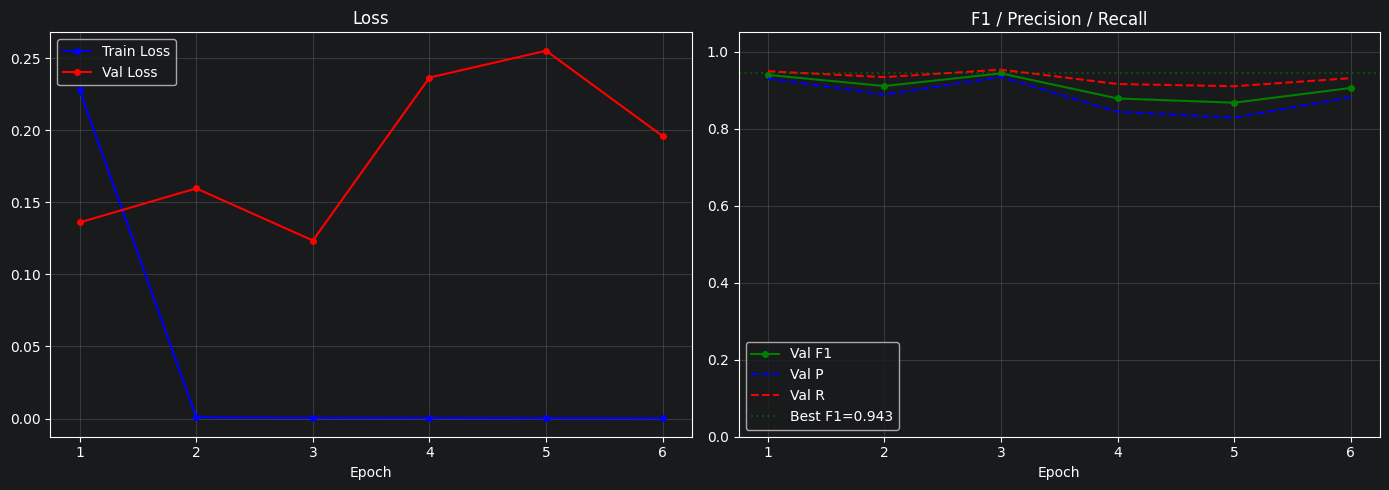

График сохранён: E:\Code\Poliforge\Polyforge-AI\Polyforge-AI\models\nlp_model_bert\training_curves.png


In [40]:
# ============================================================
# БЛОК 6: Финальная оценка на val-сете + график
# ============================================================
import matplotlib.pyplot as plt

# test_loader убран — оцениваем на val
val_loss_final, val_f1_final, val_p_final, val_r_final = evaluate_epoch(
    model, val_loader, desc="Final Val"
)

print(f"\n{'='*45}")
print(f"ФИНАЛЬНЫЕ МЕТРИКИ (val-сет):")
print(f"  Loss:      {val_loss_final:.4f}")
print(f"  F1:        {val_f1_final:.4f}")
print(f"  Precision: {val_p_final:.4f}")
print(f"  Recall:    {val_r_final:.4f}")
print(f"{'='*45}")

# Детальный отчёт по классам
model.eval()
all_preds_report, all_labels_report = [], []
with torch.no_grad():
    for batch in val_loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)
        outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
        p, l = decode_predictions(outputs.logits, labels)
        all_preds_report.extend(p)
        all_labels_report.extend(l)

print("\nОтчёт по классам:")
print(classification_report(all_labels_report, all_preds_report))

# График обучения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history["train_loss"]) + 1)
ax1.plot(epochs_range, history["train_loss"], "b-o", label="Train Loss", markersize=4)
ax1.plot(epochs_range, history["val_loss"],   "r-o", label="Val Loss",   markersize=4)
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs_range, history["val_f1"], "g-o", label="Val F1", markersize=4)
ax2.plot(epochs_range, history["val_p"],  "b--", label="Val P",  markersize=3)
ax2.plot(epochs_range, history["val_r"],  "r--", label="Val R",  markersize=3)
ax2.axhline(y=best_f1, color="g", linestyle=":", alpha=0.5, label=f"Best F1={best_f1:.3f}")
ax2.set_title("F1 / Precision / Recall")
ax2.set_xlabel("Epoch")
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(MODELS_DIR / "training_curves.png", dpi=150)
plt.show()
print(f"График сохранён: {MODELS_DIR / 'training_curves.png'}")

In [41]:
# ============================================================
# БЛОК 7: Сохранение модели и артефактов
# ============================================================
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# HuggingFace-формат
model.save_pretrained(MODELS_DIR)
tokenizer.save_pretrained(MODELS_DIR)

# Артефакты
artifacts = {
    "thresholds":        THRESHOLDS,
    "property_cols":     PROPERTY_COLS,
    "label2id":          LABEL2ID,
    "id2label":          ID2LABEL,
    "model_name":        MODEL_NAME,
    "param_units":       PARAM_UNITS,
    "version":           "3.0-bert-numeric",
    "best_val_f1":       best_f1,
    "training_history":  history,
}
with open(MODELS_DIR / "artifacts.pkl", "wb") as f:
    pickle.dump(artifacts, f)

# Маппинг: название → canonical param code
name_to_param = {}
for param, cfg in PARAM_CONFIG.items():
    for name in cfg.get("names", []):
        name_to_param[name.lower()] = param
    for code in cfg.get("codes", []):
        name_to_param[code.lower()] = param

with open(MODELS_DIR / "name_to_param.json", "w", encoding="utf-8") as f:
    json.dump(name_to_param, f, ensure_ascii=False, indent=2)

print("✅ Сохранено:")
print(f"   Модель:    {MODELS_DIR}/")
print(f"   Артефакты: {MODELS_DIR}/artifacts.pkl")
print(f"   Маппинг:   {MODELS_DIR}/name_to_param.json")
print(f"   График:    {MODELS_DIR}/training_curves.png")

✅ Сохранено:
   Модель:    E:\Code\Poliforge\Polyforge-AI\Polyforge-AI\models\nlp_model_bert/
   Артефакты: E:\Code\Poliforge\Polyforge-AI\Polyforge-AI\models\nlp_model_bert/artifacts.pkl
   Маппинг:   E:\Code\Poliforge\Polyforge-AI\Polyforge-AI\models\nlp_model_bert/name_to_param.json
   График:    E:\Code\Poliforge\Polyforge-AI\Polyforge-AI\models\nlp_model_bert/training_curves.png


In [42]:
# ============================================================
# БЛОК 8: Inference — числовой экстрактор
# ============================================================
import re

class BERTParameterExtractor:
    """
    Извлекает параметры полимера из текстового запроса.
    Модель обучена на числовых запросах вида:
      'температура плавления около 420.5 К'
      'YM не менее 1500 МПа'
    """

    def __init__(self, model_dir: Path):
        self.tokenizer = AutoTokenizer.from_pretrained(model_dir)
        self.model     = AutoModelForTokenClassification.from_pretrained(
            model_dir
        ).to(DEVICE)
        self.model.eval()

        with open(model_dir / "artifacts.pkl", "rb") as f:
            art = pickle.load(f)

        self.thresholds    = art["thresholds"]
        self.property_cols = art["property_cols"]
        self.param_units   = art.get("param_units", {})
        self.id2label      = art["id2label"]

        with open(model_dir / "name_to_param.json", encoding="utf-8") as f:
            self.name_to_param = json.load(f)

    # ----------------------------------------------------------
    # 8.1 BIO-предсказание
    # ----------------------------------------------------------
    def _predict_bio(self, text: str) -> list[tuple[str, str]]:
        """Возвращает список (слово, BIO-метка)."""
        words = re.findall(r'\w+(?:[.,]\w+)?|[^\w\s]', text)
        if not words:
            return []

        encoding = self.tokenizer(
            words,
            is_split_into_words=True,
            max_length=MAX_LENGTH,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )
        word_ids = encoding.word_ids(batch_index=0)

        with torch.no_grad():
            logits = self.model(
                input_ids      = encoding["input_ids"].to(DEVICE),
                attention_mask = encoding["attention_mask"].to(DEVICE),
            ).logits

        preds = logits.argmax(dim=-1).squeeze().cpu().numpy()

        # Берём предсказание первого субтокена каждого слова
        word_labels: dict[int, str] = {}
        for token_idx, word_id in enumerate(word_ids):
            if word_id is not None and word_id not in word_labels:
                word_labels[word_id] = self.id2label[preds[token_idx]]

        return [(words[i], word_labels.get(i, "O")) for i in range(len(words))]

    # ----------------------------------------------------------
    # 8.2 Сборка спанов из BIO
    # ----------------------------------------------------------
    def _collect_spans(self, word_labels: list[tuple[str, str]]) -> list[dict]:
        """
        Собирает пары (NAME, VALUE) из BIO-последовательности.
        Возвращает список dict с ключами name_text и value_text.
        """
        # Сначала собираем все NAME и VALUE спаны по порядку
        name_spans  = []
        value_spans = []

        current_type   = None
        current_tokens = []

        for word, label in word_labels:
            if label.startswith("B-"):
                if current_type and current_tokens:
                    span_text = " ".join(current_tokens)
                    if current_type == "NAME":
                        name_spans.append(span_text)
                    elif current_type == "VALUE":
                        value_spans.append(span_text)
                current_type   = label[2:]  # убираем "B-"
                current_tokens = [word]
            elif label.startswith("I-") and current_type == label[2:]:
                current_tokens.append(word)
            else:
                if current_type and current_tokens:
                    span_text = " ".join(current_tokens)
                    if current_type == "NAME":
                        name_spans.append(span_text)
                    elif current_type == "VALUE":
                        value_spans.append(span_text)
                current_type   = None
                current_tokens = []

        # Не забываем последний спан
        if current_type and current_tokens:
            span_text = " ".join(current_tokens)
            if current_type == "NAME":
                name_spans.append(span_text)
            elif current_type == "VALUE":
                value_spans.append(span_text)

        # Жадный матчинг i-го имени с i-м значением
        pairs = []
        for i, name in enumerate(name_spans):
            pairs.append({
                "name_text":  name,
                "value_text": value_spans[i] if i < len(value_spans) else "",
            })
        return pairs

    # ----------------------------------------------------------
    # 8.3 Парсинг числа из строки
    # ----------------------------------------------------------
    def _parse_number(self, value_text: str) -> float | None:
        """
        Пытается извлечь число из строки вида '420.5', '1 500', '0,95'.
        Возвращает float или None.
        """
        # Убираем пробелы внутри числа, заменяем запятую на точку
        cleaned = value_text.replace(" ", "").replace(",", ".")
        # Ищем число (возможно с десятичной точкой)
        match = re.search(r'\d+\.?\d*', cleaned)
        if match:
            try:
                return float(match.group())
            except ValueError:
                return None
        return None

    def _parse_value(self, value_text: str) -> tuple[str, float | None]:
        """
        Определяет тип значения и возвращает (тип, число или None).
        Тип: 'numeric' или 'categorical'
        """
        # Пробуем найти число
        cleaned = value_text.replace(",", ".").replace(" ", "")
        match   = re.search(r'\d+\.?\d*', cleaned)
        if match:
            try:
                return "numeric", float(match.group())
            except ValueError:
                pass

        # Иначе — категориальное
        return "categorical", None

    def _categorical_to_range(self, param: str, value_text: str) -> dict:
        """Конвертирует прилагательное в диапазон через THRESHOLDS."""
        t = self.thresholds.get(param)
        if t is None:
            return {"target_value": 0.5, "min": 0.0, "max": 1.0, "category": "medium"}

        text = value_text.lower()

        # Определяем категорию по ключевым словам
        low_words  = ["низк", "мал", "небольш", "минимальн", "слаб", "пониженн", "скромн"]
        high_words = ["высок", "больш", "значительн", "максимальн", "повышенн", "сильн", "отличн"]

        if any(w in text for w in low_words):
            lo, hi, cat = t["min"],  t["low"],  "low"
        elif any(w in text for w in high_words):
            lo, hi, cat = t["high"], t["max"],  "high"
        else:
            lo, hi, cat = t["low"],  t["high"], "medium"

        return {
            "target_value": (lo + hi) / 2,
            "min":          lo,
            "max":          hi,
            "category":     cat,
        }

    # ----------------------------------------------------------
    # 8.4 Маппинг имени → canonical param
    # ----------------------------------------------------------
    def _span_to_param(self, name_text: str) -> str | None:
        text = name_text.lower().strip()

        # Точное совпадение
        if text in self.name_to_param:
            return self.name_to_param[text]

        # Частичное совпадение (name содержится в запросе или наоборот)
        best_match = None
        best_len   = 0
        for name, param in self.name_to_param.items():
            if name in text or text in name:
                if len(name) > best_len:
                    best_match = param
                    best_len   = len(name)
        return best_match

    # ----------------------------------------------------------
    # 8.5 Вычисление диапазона по числовому значению
    # ----------------------------------------------------------
    def _range_for_value(self, param: str, numeric_value: float) -> dict:
        """
        Строит диапазон вокруг заданного числового значения.
        Допуск: ±15% или ±σ из обучающих данных.
        """
        t = self.thresholds.get(param)
        if t is None:
            # Нет данных — просто ±15%
            delta = abs(numeric_value) * 0.15
            return {
                "target_value": numeric_value,
                "min":          numeric_value - delta,
                "max":          numeric_value + delta,
                "category":     "user_numeric",
            }

        # Зажимаем в реальный диапазон датасета
        lo = max(t["min"], numeric_value * 0.85)
        hi = min(t["max"], numeric_value * 1.15)

        # Определяем категорию по квантилям
        if numeric_value <= t["low"]:
            category = "low"
        elif numeric_value <= t["high"]:
            category = "medium"
        else:
            category = "high"

        return {
            "target_value": numeric_value,
            "min":          lo,
            "max":          hi,
            "category":     category,
        }

    # ----------------------------------------------------------
    # 8.6 Основной метод извлечения
    # ----------------------------------------------------------
    def extract(self, query: str) -> dict:
        word_labels = self._predict_bio(query)
        pairs       = self._collect_spans(word_labels)
        result      = {}

        for pair in pairs:
            param = self._span_to_param(pair["name_text"])
            if param is None:
                continue

            value_type, numeric_val = self._parse_value(pair["value_text"])

            if value_type == "numeric" and numeric_val is not None:
                # Числовое значение → диапазон ±15%
                rng = self._range_for_value(param, numeric_val)
            else:
                # Категориальное → диапазон из квантилей
                rng = self._categorical_to_range(param, pair["value_text"])

            result[param] = {
                **rng,
                "extracted_name":  pair["name_text"],
                "extracted_value": pair["value_text"],
                "value_type":      value_type,
                "user_specified":  True,
            }

        return result

    # ----------------------------------------------------------
    # 8.7 Построение финального JSON для генератора
    # ----------------------------------------------------------
    def build_generator_json(self, query: str) -> dict:
        """Строит полный JSON: user_specified + auto_filled."""
        user_params = self.extract(query)

        auto_params = {}
        for param in self.property_cols:
            if param in user_params:
                continue
            t = self.thresholds.get(param)
            if t is None:
                continue
            auto_params[param] = {
                "target_value":  (t["low"] + t["high"]) / 2,
                "min":           t["low"],
                "max":           t["high"],
                "category":      "medium",
                "user_specified": False,
            }

        return {
            "meta": {
                "original_query":   query,
                "n_user_specified": len(user_params),
                "n_auto_filled":    len(auto_params),
            },
            "user_specified": user_params,
            "auto_filled":    auto_params,
        }


# ----------------------------------------------------------
# Тест на реальных числовых запросах
# ----------------------------------------------------------
extractor = BERTParameterExtractor(MODELS_DIR)

test_queries = [
    "температура плавления около 420 К и плотность не более 1.2 г/см³",
    "Tg не менее 350 К, модуль Юнга примерно 2000 МПа",
    "проницаемость для CO2 около 100 Баррер и Td от 500 до 600 К",
    "YM ~ 1500 МПа, рабочая температура 380К",
    "кислородный индекс не менее 28 и прочность на разрыв 45 МПа",
]

print("\n" + "="*60)
print("ТЕСТ INFERENCE")
print("="*60)
for q in test_queries:
    result = extractor.build_generator_json(q)
    print(f"\nЗапрос: {q}")
    print(f"  Найдено параметров: {result['meta']['n_user_specified']}")
    for p, v in result["user_specified"].items():
        print(f"    {p:12s}: target={v['target_value']:.2f}"
              f"  range=[{v['min']:.2f}, {v['max']:.2f}]"
              f"  cat={v['category']}"
              f"  (из текста: '{v['extracted_name']}' = '{v['extracted_value']}')")


ТЕСТ INFERENCE

Запрос: температура плавления около 420 К и плотность не более 1.2 г/см³
  Найдено параметров: 2
    Tm          : target=420.00  range=[357.00, 483.00]  cat=low  (из текста: 'температура плавления' = '420')
    rho         : target=1.20  range=[1.02, 1.38]  cat=low  (из текста: 'плотность' = '1.2')

Запрос: Tg не менее 350 К, модуль Юнга примерно 2000 МПа
  Найдено параметров: 1
    YM          : target=2000.00  range=[1700.00, 2300.00]  cat=medium  (из текста: 'модуль Юнга' = '2000')

Запрос: проницаемость для CO2 около 100 Баррер и Td от 500 до 600 К
  Найдено параметров: 1
    Td          : target=500.00  range=[447.38, 575.00]  cat=low  (из текста: 'Td' = '500')

Запрос: YM ~ 1500 МПа, рабочая температура 380К
  Найдено параметров: 1
    YM          : target=1500.00  range=[1275.00, 1725.00]  cat=low  (из текста: 'YM' = '1500')

Запрос: кислородный индекс не менее 28 и прочность на разрыв 45 МПа
  Найдено параметров: 2
    LOI         : target=28.00  range=[23.80,

In [43]:
# ============================================================
# БЛОК 9: Финальный JSON → генеративный модуль
# ============================================================
QUERY = (
    "Нужен полимер: температура плавления около 430 К, "
    "плотность не более 1.15 г/см³, "
    "модуль Юнга не менее 1800 МПа, "
    "проницаемость для CO2 порядка 50 Баррер, "
    "кислородный индекс от 25 до 35"
)

output = extractor.build_generator_json(QUERY)

out_path = DATA_PROC_DIR / "nlp_to_gen_bridge.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(output, f, indent=2, ensure_ascii=False, default=str)

print(f"\n✅ JSON сохранён: {out_path}")
print(f"\n{'='*55}")
print(f"Запрос: {QUERY[:70]}...")
print(f"Пользователь задал: {output['meta']['n_user_specified']} параметров")
print(f"Автозаполнено:       {output['meta']['n_auto_filled']} параметров")
print(f"\nПользовательские параметры:")
for p, v in output["user_specified"].items():
    print(f"  {p:15s}: {v['target_value']:10.3f}"
          f"  [{v['min']:.3f}, {v['max']:.3f}]"
          f"  ({v['category']})")
print(f"\nПример автозаполненного параметра:")
first_auto = next(iter(output["auto_filled"].items()), None)
if first_auto:
    p, v = first_auto
    print(f"  {p:15s}: {v['target_value']:10.3f}  [{v['min']:.3f}, {v['max']:.3f}]")


✅ JSON сохранён: E:\Code\Poliforge\Polyforge-AI\Polyforge-AI\data\processed\nlp_to_gen_bridge.json

Запрос: Нужен полимер: температура плавления около 430 К, плотность не более 1...
Пользователь задал: 4 параметров
Автозаполнено:       33 параметров

Пользовательские параметры:
  Tm             :    430.000  [365.500, 494.500]  (low)
  rho            :      1.150  [0.977, 1.322]  (low)
  YM             :   1800.000  [1530.000, 2070.000]  (low)
  LOI            :     25.000  [21.250, 28.750]  (low)

Пример автозаполненного параметра:
  Egc            :      3.402  [3.178, 3.625]
